In [10]:
import numpy as np  
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error,r2_score

In [18]:
housing =fetch_california_housing()
data=pd.DataFrame(housing.data,columns=housing.feature_names)
data["Price"]=housing.target

In [19]:
X=data[['AveRooms']].values
y=data['Price'].values

In [98]:
X_train,X_test,y_train,y_test = train_test_split(
    X,y,
    test_size=0.8,
    random_state=42
)

In [99]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [100]:
w=0
b=0
learning_rate =0.01
epochs = 1000
cost_history=[]
n=len(X_train_scaled)
for i in range(epochs):
    y_pred = w* X_train_scaled.flatten() +b
    cost = (1/(2*n))*np.sum((y_pred - y_train)**2)
    cost_history.append(cost)
    dw = (1/n) * np.sum((y_pred - y_train) * X_train_scaled.flatten())
    db = (1/n) * np.sum(y_pred - y_train)
    w=w - learning_rate * dw
    b=b-learning_rate * db
    if i%100 ==0:
     
      print(f"Epoch {i},cost = {cost:.4f}")
y_pred_gd = w * X_test_scaled.flatten() + b

Epoch 0,cost = 2.8193
Epoch 100,cost = 0.9492
Epoch 200,cost = 0.6986
Epoch 300,cost = 0.6650
Epoch 400,cost = 0.6605
Epoch 500,cost = 0.6599
Epoch 600,cost = 0.6599
Epoch 700,cost = 0.6598
Epoch 800,cost = 0.6598
Epoch 900,cost = 0.6598


In [101]:
print("Gradient Descent")
print("----------------")
print("weight;",w)
print("bias;",b)
print("MSE",mean_squared_error(y_test,y_pred_gd))
print("R2 Score;",r2_score(y_test,y_pred_gd))

Gradient Descent
----------------
weight; 0.1622011552292036
bias; 2.071766165873958
MSE 1.2988602093824142
R2 Score; 0.02189668273544154


In [102]:
X_train_ne = np.c_[np.ones((len(X_train),1)),X_train]
X_test_ne = np.c_[np.ones((len(X_test),1)),X_test]
theta = np.linalg.inv(X_train_ne.T @ X_train_ne) @ X_train_ne.T @ y_train 
y_pred_ne = X_test_ne @ theta

In [103]:
print("\nNormal Equation")
print("------------------")
print("Intercept;",theta[0])
print("Slope;",theta[1])
print("MSE;",mean_squared_error(y_test,y_pred_ne))
print("R2 Score;",r2_score(y_test,y_pred_ne))


Normal Equation
------------------
Intercept; 1.7877830289254806
Slope; 0.051844714648327385
MSE; 1.2988597038335623
R2 Score; 0.021897063437695374


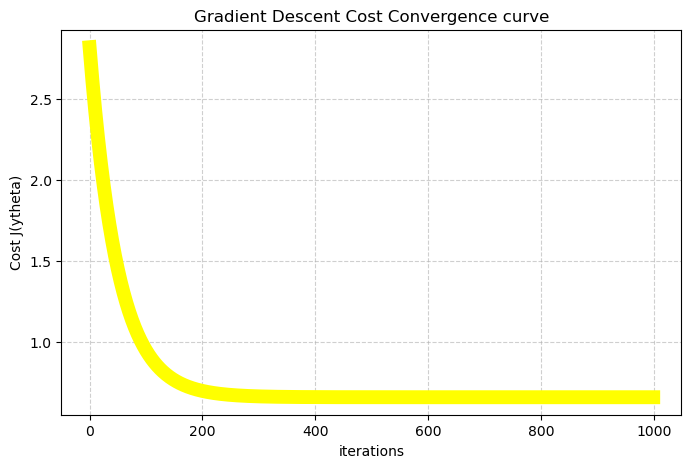

In [109]:
plt.figure(figsize=(8,5))
plt.plot(cost_history,color='yellow',linewidth=10)
plt.title('Gradient Descent Cost Convergence curve')
plt.xlabel('iterations')
plt.ylabel('Cost J(ytheta)')
plt.grid(True,linestyle='--',alpha=0.6)
plt.show()

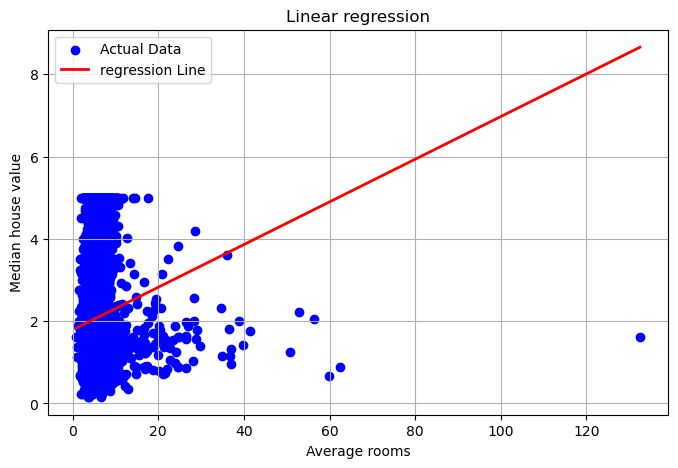

In [113]:
index=np.argsort(X_test.flatten())
plt.figure(figsize=(8,5))
plt.scatter(X_test,y_test,color='blue',label='Actual Data')
plt.plot(
    X_test.flatten()[index],y_pred_ne[index],color='red',linewidth=2,label='regression Line'
)
plt.title('Linear regression')
plt.xlabel('Average rooms')
plt.ylabel('Median house value')
plt.legend()
plt.grid(True)
plt.show()
